In [1]:
import numpy as np
import pandas as pd

df = pd.read_parquet("data/requests/ann-arbor.parquet")
df["pick_lat"] = np.rad2deg(df["pick_lat"])
df["pick_lon"] = np.rad2deg(df["pick_lon"])
df["drop_lat"] = np.rad2deg(df["drop_lat"])
df["drop_lon"] = np.rad2deg(df["drop_lon"])

df.head()

,created_at,pick_lat,pick_lon,drop_lat,drop_lon,pax,pick_hex,drop_hex,predicted_lm_dist
0,0,42.320301,-83.690285,42.286003,-83.746696,1,604233477973344255,604173502378934271,8.217588
1,0,42.259121,-83.767838,42.254631,-83.769783,1,604173502378934271,604173502378934271,1.238919
2,0,42.324047,-83.707939,42.306217,-83.738449,3,604233477973344255,604233477973344255,4.642469
3,1,42.255489,-83.730743,42.260651,-83.727791,1,604173502378934271,604173502378934271,1.365432
4,1,42.237061,-83.739258,42.274529,-83.692513,2,604233474215247871,604233478107561983,7.790916


In [29]:
import datashader as ds
import datashader.transfer_functions as tf
from pyproj import Transformer
import contextily as cx
from PIL import Image


def crop_img_to_mercator_extent(img, img_extent, target_extent):
    left, right, bottom, top = img_extent
    x0, x1, y0, y1 = target_extent

    w, h = img.size

    px0 = round((x0 - left) / (right - left) * w)
    px1 = round((x1 - left) / (right - left) * w)

    py0 = round((top - y1) / (top - bottom) * h)
    py1 = round((top - y0) / (top - bottom) * h)

    return img.crop((px0, py0, px1, py1))


def render_basemap(x_range, y_range, size):
    target_extent = (x_range[0], x_range[1], y_range[0], y_range[1])

    basemap = cx.providers.CartoDB.DarkMatterNoLabels
    labelsmap = cx.providers.CartoDB.DarkMatterOnlyLabels

    base, base_extent = cx.bounds2img(x_range[0], y_range[0], x_range[1], y_range[1],
                                      ll=False, source=basemap, zoom=14)

    labels, labels_extent = cx.bounds2img(x_range[0], y_range[0], x_range[1], y_range[1],
                                          ll=False, source=labelsmap, zoom=13)

    base_img = Image.fromarray(base).convert("RGBA")
    labels_img = Image.fromarray(labels).convert("RGBA")

    base_img = (crop_img_to_mercator_extent(base_img, base_extent, target_extent)
                .resize(size, Image.Resampling.BILINEAR))
    labels_img = (crop_img_to_mercator_extent(labels_img, labels_extent, target_extent)
                  .resize(size, Image.Resampling.LANCZOS))

    return base_img, labels_img


def render_trips(df, out: str = None, width: int = 500, q: float = 0.001, bbox_latlon=None,
                 cmap=("#0b0b0b", "#2b0d0a", "#5c1a0f", "#a33a17", "#ff7b2c", "#ffd08a", "#fff2de")):
    """
    @param bbox_latlon: (min_lon, min_lat, max_lon, max_lat)
    """

    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

    x0, y0 = transformer.transform(df["pick_lon"].to_numpy(), df["pick_lat"].to_numpy())
    x1, y1 = transformer.transform(df["drop_lon"].to_numpy(), df["drop_lat"].to_numpy())

    trips = pd.DataFrame({"x0": x0, "y0": y0, "x1": x1, "y1": y1}).replace([np.inf, -np.inf], np.nan).dropna()

    if bbox_latlon is not None:
        min_lon, min_lat, max_lon, max_lat = bbox_latlon
        xmin, ymin = transformer.transform(min_lon, min_lat)
        xmax, ymax = transformer.transform(max_lon, max_lat)
        x_range = (xmin, xmax)
        y_range = (ymin, ymax)

    else:
        xs = np.concatenate([trips["x0"].to_numpy(), trips["x1"].to_numpy()])
        ys = np.concatenate([trips["y0"].to_numpy(), trips["y1"].to_numpy()])
        x_range = tuple(np.quantile(xs, [q, 1 - q]))
        y_range = tuple(np.quantile(ys, [q, 1 - q]))

    aspect = (x_range[1] - x_range[0]) / (y_range[1] - y_range[0])
    height = round(width / aspect)

    canvas = ds.Canvas(plot_width=width, plot_height=height, x_range=x_range, y_range=y_range)

    agg = canvas.line(trips, x=["x0", "x1"], y=["y0", "y1"],
                      axis=1, agg=ds.count(), antialias=False)

    trips_img = tf.shade(agg, cmap=cmap, how="eq_hist").to_pil().convert("RGBA")

    base_img, labels_img = render_basemap(x_range, y_range, size=trips_img.size)

    final = Image.alpha_composite(base_img, trips_img)
    final = Image.alpha_composite(final, labels_img)

    if out:
        final.save(out)
    return final

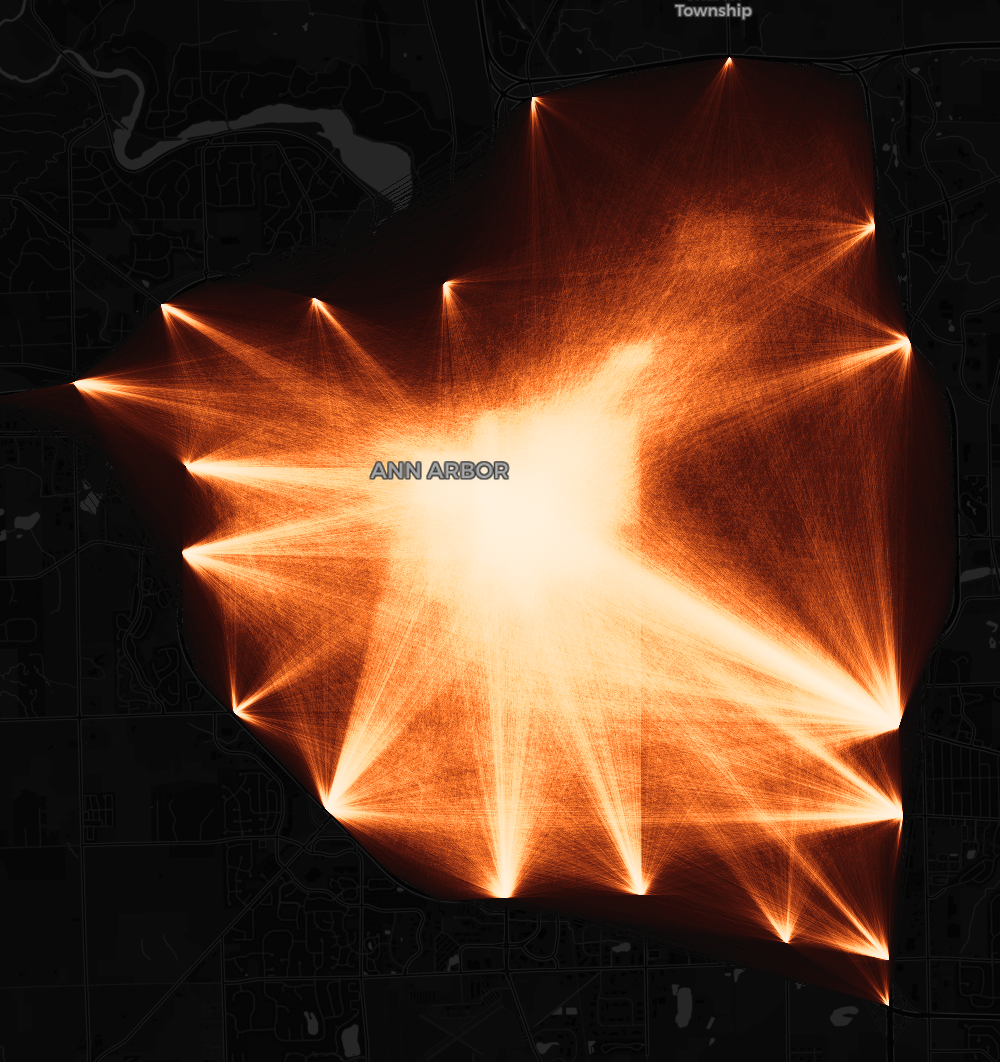

In [33]:
ann_arbor_bbox = (-83.81, 42.22, -83.67, 42.33)
render_trips(df.sample(n=500000), width=1000, bbox_latlon=ann_arbor_bbox)